# Task 5: Personal Loan Acceptance Prediction
**DevelopersHub Corporation | Data Science & Analytics Internship**

# **By: Muhammad Yahya Imran**

---

**Objective:** Predict which customers are likely to accept a personal loan offer based on features like age, job, income, and marital status.

**Dataset:** Bank Marketing Dataset (UCI Machine Learning Repository via Kaggle)

**Steps:** Data Loading → Inspection → EDA → Preprocessing → Model Training → Evaluation → Conclusion

## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_theme(style='darkgrid')
plt.rcParams['figure.dpi'] = 110
print('Libraries imported successfully.')

Libraries imported successfully.


## Step 2: Load Dataset from Kaggle

In [2]:
# Uncomment below to install kagglehub if not already present
# !pip install kagglehub

import kagglehub
import os

path = kagglehub.dataset_download('henriqueyamahata/bank-marketing')
print('Dataset downloaded to:', path)

# Load the dataset
csv_file = os.path.join(path, 'bank-additional-full.csv')
df = pd.read_csv(csv_file, sep=';')

print('Dataset Shape:', df.shape)
df.head(10)

100%|██████████| 393k/393k [00:00<00:00, 765kB/s]

Extracting files...
Dataset downloaded to: /root/.cache/kagglehub/datasets/henriqueyamahata/bank-marketing/versions/1
Dataset Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
7,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
8,24,technician,single,professional.course,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
9,25,services,single,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Step 3: Dataset Inspection

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [4]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [5]:
# Inspect for any missing entries
print('Missing values:')
print(df.isnull().sum())

# Check target column
print('\nTarget (y) distribution:')
print(df['y'].value_counts())

Missing values:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Target (y) distribution:
y
no     36548
yes     4640
Name: count, dtype: int64


## Step 4: Exploratory Data Analysis (EDA)

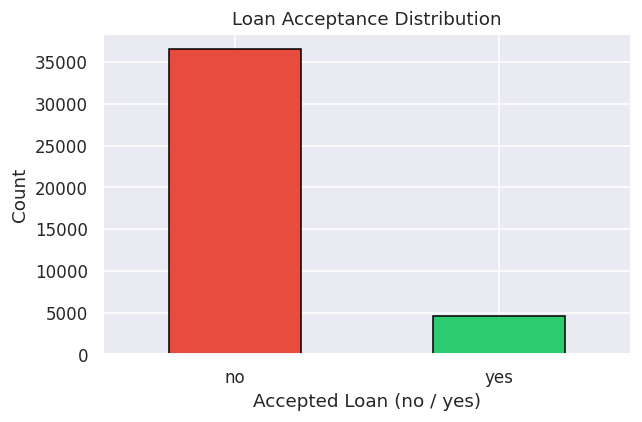

Acceptance rate: 11.27 %


In [6]:
# Bar chart showing the balance of accepted vs rejected cases
plt.figure(figsize=(6, 4))
df['y'].value_counts().plot(kind='bar', color=['#E74C3C', '#2ECC71'], edgecolor='black')
plt.title('Loan Acceptance Distribution')
plt.xlabel('Accepted Loan (no / yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print('Acceptance rate:', round(df['y'].value_counts(normalize=True)['yes'] * 100, 2), '%')

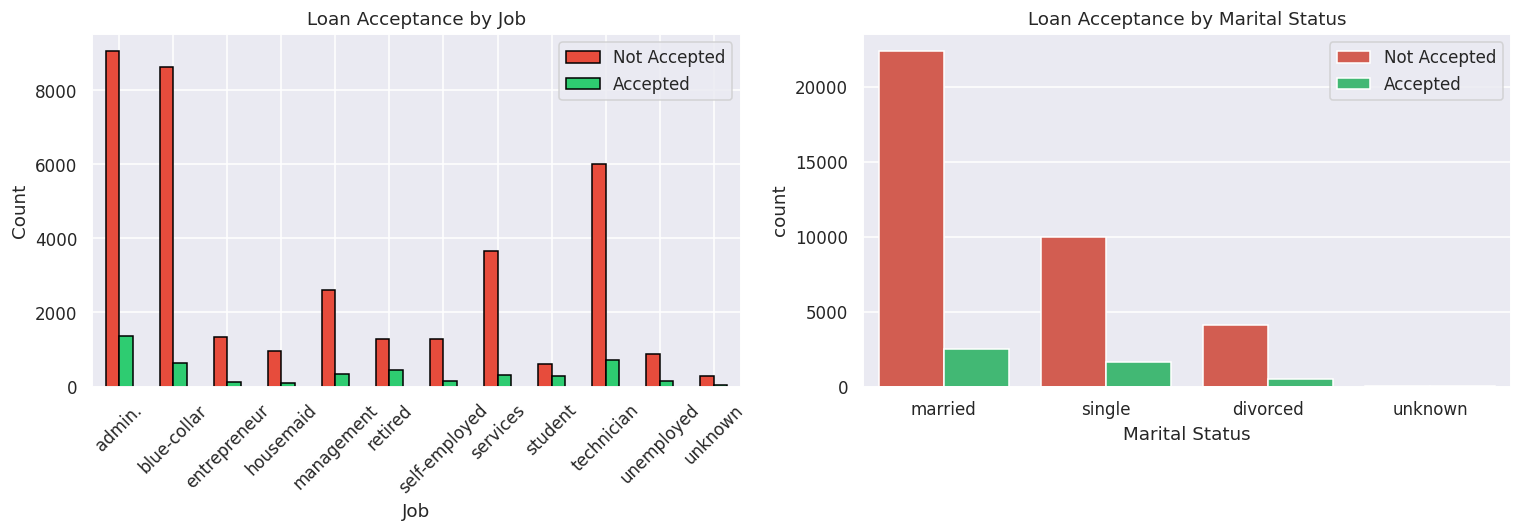

In [7]:
# Group acceptance rates by occupation and relationship status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

job_counts = df.groupby(['job', 'y']).size().unstack(fill_value=0)
job_counts.plot(kind='bar', ax=axes[0], color=['#E74C3C', '#2ECC71'], edgecolor='black')
axes[0].set_title('Loan Acceptance by Job')
axes[0].set_xlabel('Job')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(['Not Accepted', 'Accepted'])

sns.countplot(data=df, x='marital', hue='y', ax=axes[1],
              palette={'no': '#E74C3C', 'yes': '#2ECC71'})
axes[1].set_title('Loan Acceptance by Marital Status')
axes[1].set_xlabel('Marital Status')
axes[1].legend(['Not Accepted', 'Accepted'])

plt.tight_layout()
plt.show()

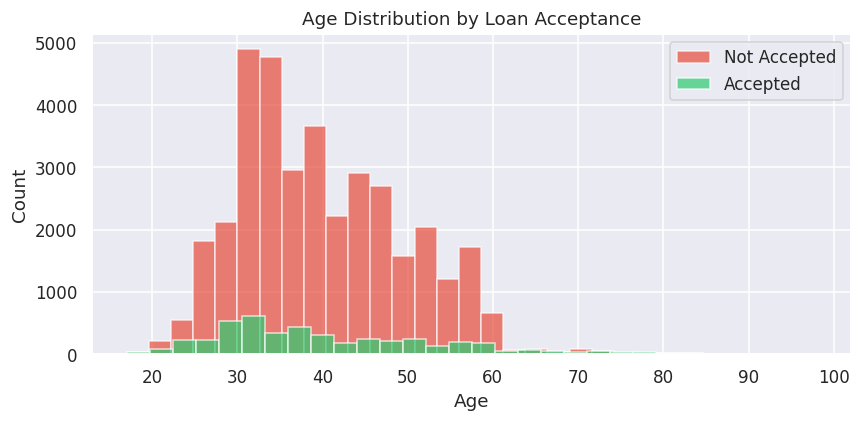

In [8]:
# Overlapping age histograms by acceptance outcome
plt.figure(figsize=(8, 4))
df[df['y'] == 'no']['age'].hist(bins=30, alpha=0.7, color='#E74C3C', label='Not Accepted')
df[df['y'] == 'yes']['age'].hist(bins=30, alpha=0.7, color='#2ECC71', label='Accepted')
plt.title('Age Distribution by Loan Acceptance')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

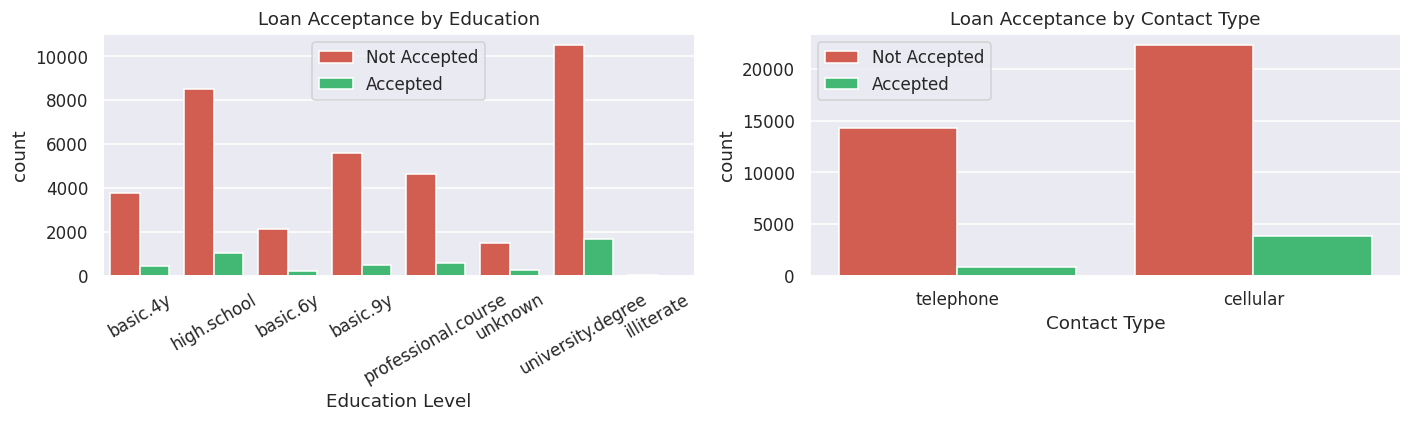

In [9]:
# Acceptance breakdown across education levels and contact channels
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.countplot(data=df, x='education', hue='y', ax=axes[0],
              palette={'no': '#E74C3C', 'yes': '#2ECC71'})
axes[0].set_title('Loan Acceptance by Education')
axes[0].set_xlabel('Education Level')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(['Not Accepted', 'Accepted'])

sns.countplot(data=df, x='contact', hue='y', ax=axes[1],
              palette={'no': '#E74C3C', 'yes': '#2ECC71'})
axes[1].set_title('Loan Acceptance by Contact Type')
axes[1].set_xlabel('Contact Type')
axes[1].legend(['Not Accepted', 'Accepted'])

plt.tight_layout()
plt.show()

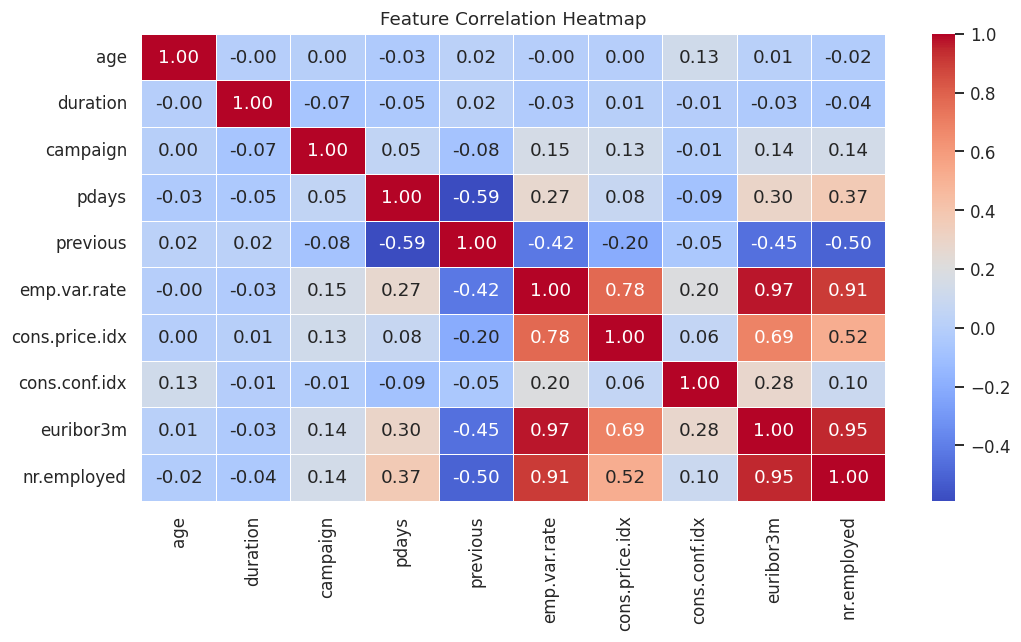

In [10]:
# Heatmap of pairwise feature correlations on numeric columns
plt.figure(figsize=(10, 6))
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## Step 5: Data Cleaning & Preprocessing

In [11]:
df_clean = df.copy()

# Convert all object-type columns to numeric via label encoding
le = LabelEncoder()
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

print('Encoding complete.')
print('Missing values:', df_clean.isnull().sum().sum())
df_clean.head()

Encoding complete.
Missing values: 0


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,3,1,0,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57,7,1,3,1,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37,7,1,3,0,2,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40,0,1,1,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56,7,1,3,0,0,2,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0


In [12]:
# Separate input features from the prediction target
X = df_clean.drop(columns=['y'])
y = df_clean['y']

# Partition data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalise features using standard scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Training samples:', X_train.shape[0])
print('Testing samples :', X_test.shape[0])

Training samples: 32950
Testing samples : 8238


## Step 6: Model Training

In [13]:
# Train Logistic Regression as the baseline classifier
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_acc  = accuracy_score(y_test, lr_pred)

print('Logistic Regression')
print('Accuracy:', round(lr_acc, 4))

Logistic Regression
Accuracy: 0.9139


In [14]:
# Train a Decision Tree for comparison
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)
dt_pred = dt_model.predict(X_test_scaled)
dt_acc  = accuracy_score(y_test, dt_pred)

print('Decision Tree')
print('Accuracy:', round(dt_acc, 4))

Decision Tree
Accuracy: 0.8956


## Step 7: Model Evaluation

In [15]:
# Detailed per-class performance reports
print('===== Logistic Regression =====')
print(classification_report(y_test, lr_pred, target_names=['Not Accepted', 'Accepted']))

print('===== Decision Tree =====')
print(classification_report(y_test, dt_pred, target_names=['Not Accepted', 'Accepted']))

===== Logistic Regression =====
              precision    recall  f1-score   support

Not Accepted       0.93      0.98      0.95      7310
    Accepted       0.70      0.41      0.52       928

    accuracy                           0.91      8238
   macro avg       0.81      0.70      0.74      8238
weighted avg       0.90      0.91      0.90      8238

===== Decision Tree =====
              precision    recall  f1-score   support

Not Accepted       0.94      0.94      0.94      7310
    Accepted       0.53      0.57      0.55       928

    accuracy                           0.90      8238
   macro avg       0.74      0.75      0.75      8238
weighted avg       0.90      0.90      0.90      8238



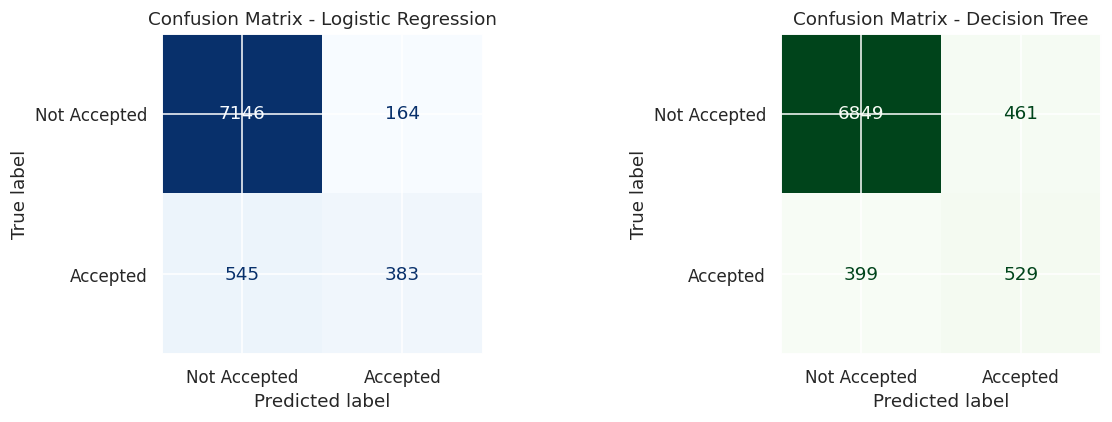

In [16]:
# Side-by-side confusion matrices for model comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay(confusion_matrix(y_test, lr_pred),
    display_labels=['Not Accepted', 'Accepted']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix - Logistic Regression')

ConfusionMatrixDisplay(confusion_matrix(y_test, dt_pred),
    display_labels=['Not Accepted', 'Accepted']).plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Confusion Matrix - Decision Tree')

plt.tight_layout()
plt.show()

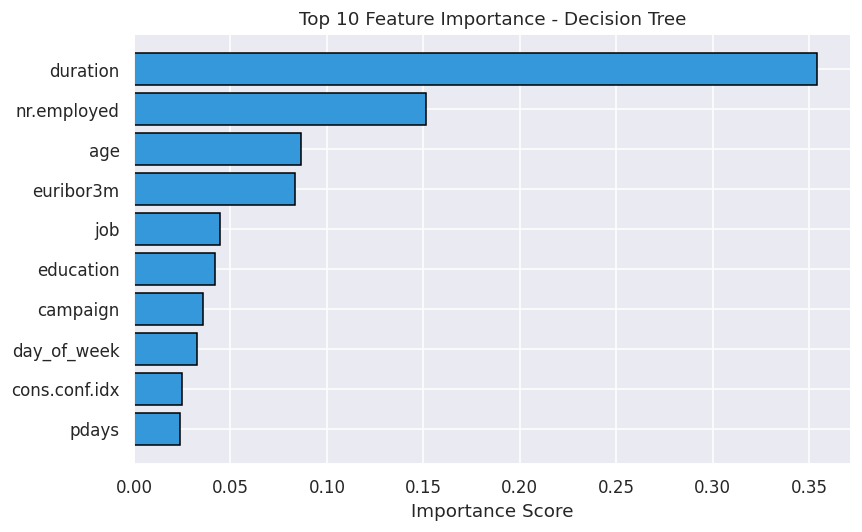

In [17]:
# Bar chart of feature contribution scores - Decision Tree
feat_imp = pd.DataFrame({
    'Feature'   : X.columns.tolist(),
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=True).tail(10)

plt.figure(figsize=(8, 5))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='#3498DB', edgecolor='black')
plt.title('Top 10 Feature Importance - Decision Tree')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

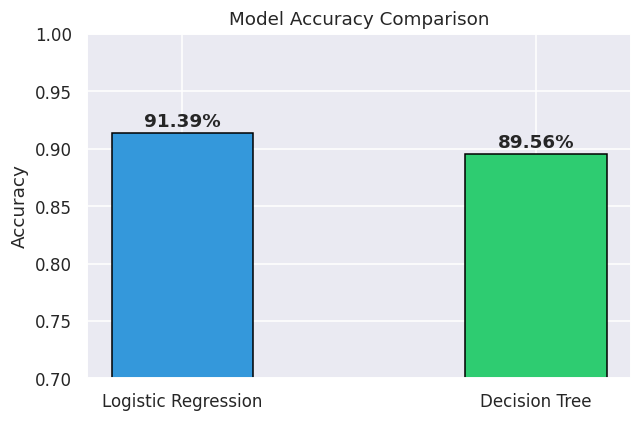

In [18]:
# Visual comparison of model accuracies
plt.figure(figsize=(6, 4))
models     = ['Logistic Regression', 'Decision Tree']
accuracies = [lr_acc, dt_acc]
bars = plt.bar(models, accuracies, color=['#3498DB', '#2ECC71'], edgecolor='black', width=0.4)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.7, 1.0)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.005,
             f'{acc:.2%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Step 8: Conclusion

In [19]:
best     = 'Logistic Regression' if lr_acc >= dt_acc else 'Decision Tree'
best_acc = max(lr_acc, dt_acc)

print('Model Comparison:')
comparison = pd.DataFrame({
    'Model'   : ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [round(lr_acc, 4), round(dt_acc, 4)]
})
print(comparison.to_string(index=False))
print(f'\nBetter Model: {best} with accuracy of {best_acc:.2%}')
print('\nKey Findings:')
print('  - The dataset is imbalanced — most customers did not accept the loan offer.')
print('  - Students and retired customers showed higher loan acceptance rates.')
print('  - Customers contacted via cellular had higher acceptance rates than telephone.')
print('  - Single customers were slightly more likely to accept the offer than married ones.')
print('  - Duration of last contact and number of previous contacts are strong predictors.')
print(f'  - {best} performed better overall with an accuracy of {best_acc:.2%}.')

Model Comparison:
              Model  Accuracy
Logistic Regression    0.9139
      Decision Tree    0.8956

Better Model: Logistic Regression with accuracy of 91.39%

Key Findings:
  - The dataset is imbalanced — most customers did not accept the loan offer.
  - Students and retired customers showed higher loan acceptance rates.
  - Customers contacted via cellular had higher acceptance rates than telephone.
  - Single customers were slightly more likely to accept the offer than married ones.
  - Duration of last contact and number of previous contacts are strong predictors.
  - Logistic Regression performed better overall with an accuracy of 91.39%.
